# QRT ENS Data Challenge - LightGBM Pipeline

This notebook implements a complete LightGBM pipeline to predict electricity price variations. 
It includes data preprocessing, feature engineering, cross-validation, and submission generation.

In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from scipy.stats import spearmanr
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [2]:
X_train = pd.read_csv('X_train.csv')
Y_train = pd.read_csv('y_train.csv')
X_test = pd.read_csv('X_test_final.csv')

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

X_train shape: (1494, 35)
X_test shape: (654, 35)


## 2. Preprocessing & Feature Engineering

We will:
- Encode the `COUNTRY` feature.
- Create new features based on the differences between Germany (DE) and France (FR) metrics.
- Handle missing values (though LightGBM can handle them natively).

In [3]:
def preprocess(df):
    df = df.copy()
    
    # 1. Encode COUNTRY (0 for DE, 1 for FR)
    df['COUNTRY_CODE'] = df['COUNTRY'].map({'DE': 0, 'FR': 1})
    
    # 2. Feature engineering: differences between countries
    # Many features are available for both DE and FR. The spread between them often drives prices.
    common_features = [
        'CONSUMPTION', 'GAS', 'COAL', 'HYDRO', 'NUCLEAR', 
        'SOLAR', 'WINDPOW', 'RAIN', 'WIND', 'TEMP', 'RESIDUAL_LOAD'
    ]
    
    for feat in common_features:
        de_col = f'DE_{feat}'
        fr_col = f'FR_{feat}'
        if de_col in df.columns and fr_col in df.columns:
            df[f'SPREAD_{feat}'] = df[de_col] - df[fr_col]
            
    # 3. Add interactions or ratios if needed (optional)
    # For example, net import/export spread
    if 'DE_NET_EXPORT' in df.columns and 'FR_NET_EXPORT' in df.columns:
        df['SPREAD_NET_EXPORT'] = df['DE_NET_EXPORT'] - df['FR_NET_EXPORT']
        
    return df

X_train_processed = preprocess(X_train)
X_test_processed = preprocess(X_test)

# Target variable
y_train = Y_train['TARGET']

# Features to use for training (dropping IDs and the original categorical COUNTRY)
cols_to_drop = ['ID', 'DAY_ID', 'COUNTRY']
train_cols = [c for c in X_train_processed.columns if c not in cols_to_drop]

print(f'Number of features: {len(train_cols)}')
print(f'Features: {train_cols}')

Number of features: 45
Features: ['DE_CONSUMPTION', 'FR_CONSUMPTION', 'DE_FR_EXCHANGE', 'FR_DE_EXCHANGE', 'DE_NET_EXPORT', 'FR_NET_EXPORT', 'DE_NET_IMPORT', 'FR_NET_IMPORT', 'DE_GAS', 'FR_GAS', 'DE_COAL', 'FR_COAL', 'DE_HYDRO', 'FR_HYDRO', 'DE_NUCLEAR', 'FR_NUCLEAR', 'DE_SOLAR', 'FR_SOLAR', 'DE_WINDPOW', 'FR_WINDPOW', 'DE_LIGNITE', 'DE_RESIDUAL_LOAD', 'FR_RESIDUAL_LOAD', 'DE_RAIN', 'FR_RAIN', 'DE_WIND', 'FR_WIND', 'DE_TEMP', 'FR_TEMP', 'GAS_RET', 'COAL_RET', 'CARBON_RET', 'COUNTRY_CODE', 'SPREAD_CONSUMPTION', 'SPREAD_GAS', 'SPREAD_COAL', 'SPREAD_HYDRO', 'SPREAD_NUCLEAR', 'SPREAD_SOLAR', 'SPREAD_WINDPOW', 'SPREAD_RAIN', 'SPREAD_WIND', 'SPREAD_TEMP', 'SPREAD_RESIDUAL_LOAD', 'SPREAD_NET_EXPORT']


## 3. Model Training with Cross-Validation

We use a 5-fold cross-validation strategy. Since the goal is Spearman correlation (rank-based), we optimize for MSE which is a good proxy for regression tasks.

In [4]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))
feature_importances = pd.DataFrame(index=train_cols)

lgbm_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'learning_rate': 0.03,
    'num_leaves': 31,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_processed)):
    X_tr, X_val = X_train_processed.iloc[train_idx][train_cols], X_train_processed.iloc[val_idx][train_cols]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = lgb.LGBMRegressor(**lgbm_params, n_estimators=1000)
    
    model.fit(
        X_tr, y_tr, 
        eval_set=[(X_val, y_val)], 
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
    )
    
    oof_preds[val_idx] = model.predict(X_val)
    test_preds += model.predict(X_test_processed[train_cols]) / kf.n_splits
    feature_importances[f'fold_{fold}'] = model.feature_importances_

spearman_score = spearmanr(y_train, oof_preds).correlation
print(f'\nFinal OOF Spearman Correlation: {spearman_score:.4f}')

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[15]	valid_0's rmse: 1.08592
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[17]	valid_0's rmse: 1.10414
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[33]	valid_0's rmse: 1.0205
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[30]	valid_0's rmse: 0.876235
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[18]	valid_0's rmse: 1.00281

Final OOF Spearman Correlation: 0.1764


## 4. Feature Importance

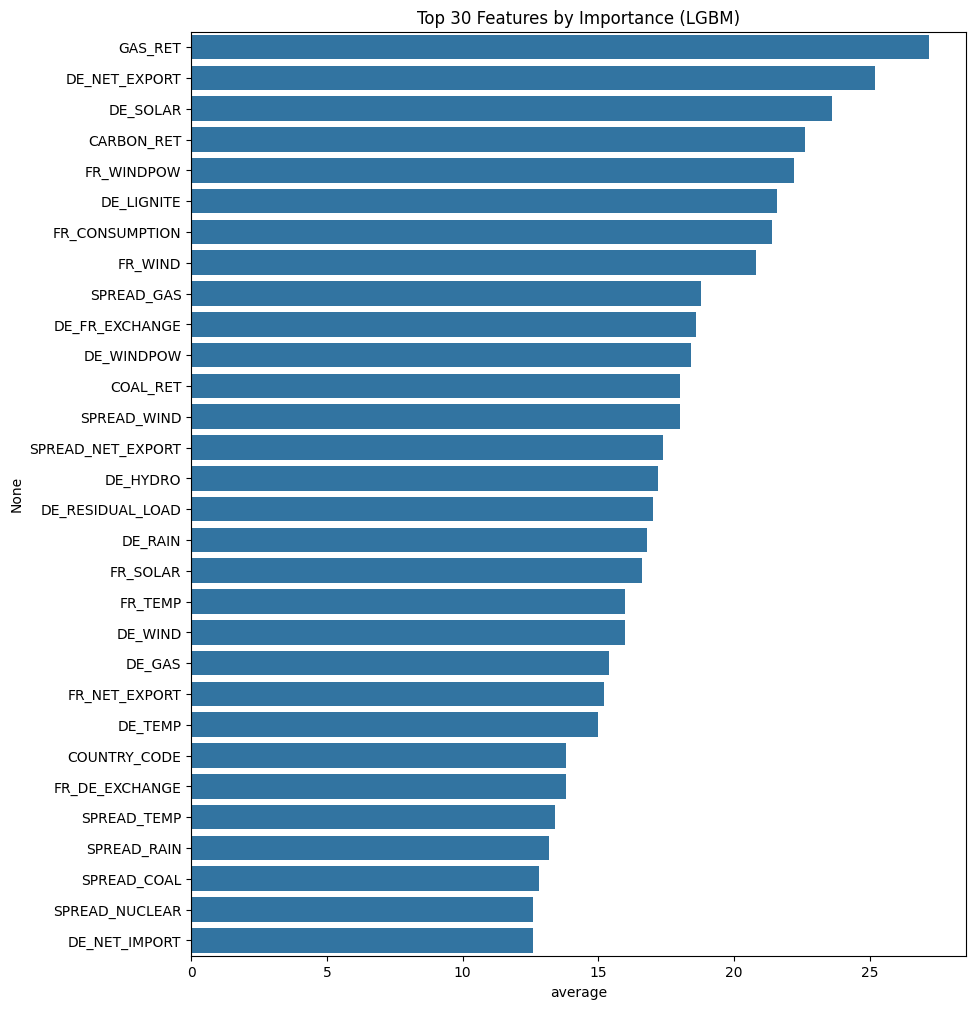

In [5]:
feature_importances['average'] = feature_importances[[f'fold_{i}' for i in range(kf.n_splits)]].mean(axis=1)
sorted_importances = feature_importances.sort_values('average', ascending=False).head(30)

plt.figure(figsize=(10, 12))
sns.barplot(x='average', y=sorted_importances.index, data=sorted_importances)
plt.title('Top 30 Features by Importance (LGBM)')
plt.show()

## 5. Submission

In [6]:
submission = X_test[['ID']].copy()
submission['TARGET'] = test_preds
submission.to_csv('submission_lgbm.csv', index=False)
print("Submission saved to 'submission_lgbm.csv'")

Submission saved to 'submission_lgbm.csv'
